In [ ]:
# Jupyter Cell 1 — imports
import math
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

In [2]:
# Jupyter Cell 2 — helpers (patchify/unpatchify + metrics + viz)

def rgb_to_y(img: torch.Tensor) -> torch.Tensor:
    r, g, b = img[:, 0:1], img[:, 1:2], img[:, 2:3]
    return 0.299 * r + 0.587 * g + 0.114 * b

def to_m1p1(x01: torch.Tensor) -> torch.Tensor:
    return x01 * 2.0 - 1.0

def to_01(xm1p1: torch.Tensor) -> torch.Tensor:
    return (xm1p1 + 1.0) * 0.5

def psnr_from_mse(mse: float, max_val: float = 1.0) -> float:
    if mse <= 1e-12:
        return 99.0
    return 10.0 * math.log10((max_val * max_val) / mse)

@torch.no_grad()
def patchify(x: torch.Tensor, patch_size: int):
    """
    x: [B,C,H,W]
    returns patches: [B, L, C, P, P], plus grid (gh, gw)
    """
    B, C, H, W = x.shape
    P = patch_size
    assert H % P == 0 and W % P == 0, "For this test, use images divisible by patch_size."
    gh, gw = H // P, W // P
    patches = F.unfold(x, kernel_size=P, stride=P)          # [B, C*P*P, L]
    patches = patches.transpose(1, 2).contiguous()          # [B, L, C*P*P]
    patches = patches.view(B, gh * gw, C, P, P)             # [B, L, C, P, P]
    return patches, (gh, gw)

@torch.no_grad()
def unpatchify(patches: torch.Tensor, grid_hw):
    """
    patches: [B, L, C, P, P]
    return x: [B,C,H,W]
    """
    B, L, C, P, _ = patches.shape
    gh, gw = grid_hw
    assert L == gh * gw
    patches_flat = patches.view(B, L, C * P * P).transpose(1, 2).contiguous()  # [B, C*P*P, L]
    x = F.fold(patches_flat, output_size=(gh * P, gw * P), kernel_size=P, stride=P)
    return x

def patch_features(patches: torch.Tensor, remove_mean: bool = True, l2_normalize: bool = False) -> torch.Tensor:
    """
    patches: [N,C,P,P] -> [N,D]
    """
    x = patches.flatten(1)
    if remove_mean:
        x = x - x.mean(dim=1, keepdim=True)
    if l2_normalize:
        x = F.normalize(x, dim=1, eps=1e-8)
    return x

@torch.no_grad()
def nearest_centroid(x: torch.Tensor, centroids: torch.Tensor, chunk_size: int = 8192):
    """
    x: [N,D], centroids: [K,D]
    returns idx [N], d2 [N]
    """
    N, D = x.shape
    K = centroids.shape[0]
    c2 = (centroids * centroids).sum(dim=1).view(1, K)

    idx_out = torch.empty(N, device=x.device, dtype=torch.long)
    d2_out = torch.empty(N, device=x.device, dtype=x.dtype)

    for s in range(0, N, chunk_size):
        t = min(s + chunk_size, N)
        xs = x[s:t]
        x2 = (xs * xs).sum(dim=1, keepdim=True)
        d2 = x2 + c2 - 2.0 * (xs @ centroids.t())
        d2min, idx = torch.min(d2, dim=1)
        idx_out[s:t] = idx
        d2_out[s:t] = d2min
    return idx_out, d2_out

def show_triplet(x01, xhat01, title=""):
    """
    x01,xhat01: [C,H,W] in [0,1]
    """
    err = (x01 - xhat01).abs()
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    if x01.shape[0] == 1:
        axes[0].imshow(x01[0].cpu(), vmin=0, vmax=1, cmap="gray")
        axes[1].imshow(xhat01[0].cpu(), vmin=0, vmax=1, cmap="gray")
        axes[2].imshow(err[0].cpu(), vmin=0, vmax=1, cmap="gray")
    else:
        axes[0].imshow(x01.permute(1,2,0).cpu().clamp(0,1))
        axes[1].imshow(xhat01.permute(1,2,0).cpu().clamp(0,1))
        axes[2].imshow(err.permute(1,2,0).cpu().clamp(0,1))
    axes[0].set_title("original")
    axes[1].set_title("recon (exemplars)")
    axes[2].set_title("|error|")
    for a in axes: a.axis("off")
    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()


In [ ]:
# Jupyter Cell 3 — load the exemplar codebook checkpoint

CKPT_PATH = "/home/yyh/python_workspaces/rhino-opsr/ema_kmeans_centroids.pt"   # <- your saved file
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

ckpt = torch.load(CKPT_PATH, map_location="cpu")

cfg = ckpt["cfg"]
state = ckpt["state"]
extra = ckpt.get("extra", None)

# centroids always exist
centroids = state["centroids"].to(DEVICE).float()

# exemplars (if you saved them under extra from find_exemplars)
assert extra is not None and "exemplar_p?atches" in extra, "Checkpoint missing exemplar_patches. Save with extra=ex in save_codebook()."
exemplar_patches = extra["exemplar_patches"].to(DEVICE).float()   # [K,C,P,P] in [-1,1] as saved
exemplar_found = extra["exemplar_found"].to(DEVICE)
hit_count = extra.get("hit_count", state.get("hit_count", None))
if hit_count is not None:
    hit_count = hit_count.to(DEVICE)

P = int(cfg["patch_size"])
in_ch = int(cfg["in_ch"])
remove_mean = bool(cfg.get("remove_mean", True))
l2_normalize = bool(cfg.get("l2_normalize", False))

print("Loaded:")
print(f"  K={centroids.shape[0]}, patch_size={P}, in_ch={in_ch}")
print(f"  exemplars found: {int(exemplar_found.sum().item())}/{centroids.shape[0]}")


TypeError: 'NoneType' object is not subscriptable

In [10]:
# Jupyter Cell 4 — load one image from an ImageFolder dataset (or replace with your own tensor)

DATA_ROOT = "/home/yyh/python_workspaces/rhino-opsr/data/ImageNet/ILSVRC2012_train/val"  # ImageFolder
IMAGE_SIZE = 256
BATCH_SIZE = 1
NUM_WORKERS = 0  # safer for notebooks

tfm = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),  # [0,1]
])

ds = ImageFolder(DATA_ROOT, transform=tfm)
dl = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=False)

imgs01, _ = next(iter(dl))  # [1,3,H,W]
imgs01 = imgs01.to(DEVICE)

# if codebook is Y-channel, convert
if in_ch == 1:
    imgs01 = rgb_to_y(imgs01)

# normalize to [-1,1]
x = to_m1p1(imgs01)  # [1,C,H,W] in [-1,1]
print("x shape:", tuple(x.shape))
assert x.shape[-1] % P == 0 and x.shape[-2] % P == 0, "Use IMAGE_SIZE divisible by patch_size for this test."


x shape: (1, 1, 256, 256)


MSE=0.169964  L1=0.358572  PSNR=7.70 dB
idx stats: min 2 max 8191 unique 622
d2 mean: 0.06861387193202972 d2 median: 0.06680198013782501


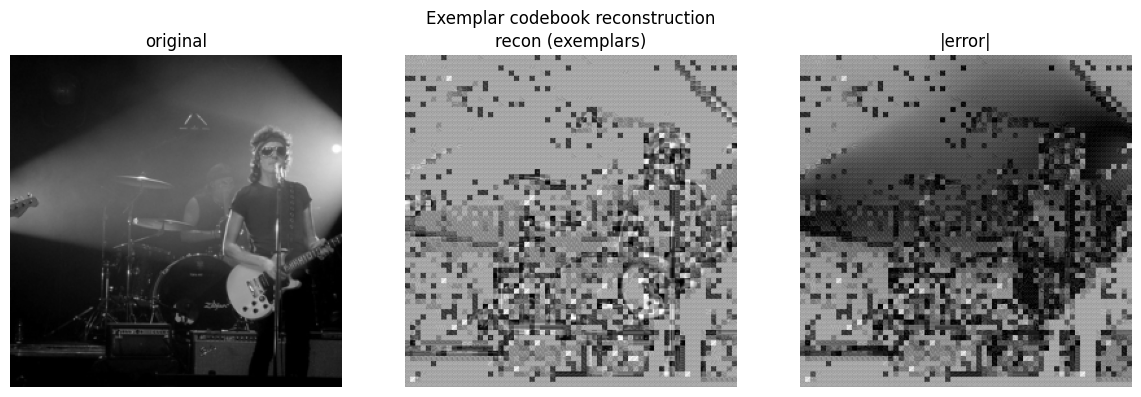

In [11]:
# Jupyter Cell 5 — reconstruct using EXEMPLARS (nearest centroid -> exemplar patch)

@torch.no_grad()
def reconstruct_with_exemplars(
    x_m1p1: torch.Tensor,      # [1,C,H,W] in [-1,1]
    exemplar_patches: torch.Tensor,  # [K,C,P,P] in [-1,1]
    centroids: torch.Tensor,         # [K,D] feature-space centroids
    patch_size: int,
    remove_mean: bool = True,
    l2_normalize: bool = False,
    nn_chunk_size: int = 8192,
):
    # patchify
    patches, grid = patchify(x_m1p1, patch_size=patch_size)  # [1,L,C,P,P]
    B, L, C, P, _ = patches.shape
    patchesN = patches.view(L, C, P, P)                      # [L,C,P,P]

    # features
    feats = patch_features(patchesN, remove_mean=remove_mean, l2_normalize=l2_normalize)  # [L,D]

    # nearest centroid index per patch
    idx, d2 = nearest_centroid(feats, centroids, chunk_size=nn_chunk_size)  # [L], [L]

    # gather exemplars
    recon_patchesN = exemplar_patches.index_select(0, idx)  # [L,C,P,P]

    # unpatchify
    recon = unpatchify(recon_patchesN.view(1, L, C, P, P), grid)  # [1,C,H,W]

    return recon, idx, d2

x_hat, idx, d2 = reconstruct_with_exemplars(
    x_m1p1=x,
    exemplar_patches=exemplar_patches,
    centroids=centroids,
    patch_size=P,
    remove_mean=remove_mean,
    l2_normalize=l2_normalize,
)

# back to [0,1]
x01 = to_01(x).clamp(0,1)[0]
xhat01 = to_01(x_hat).clamp(0,1)[0]

mse = F.mse_loss(xhat01, x01).item()
l1 = F.l1_loss(xhat01, x01).item()
psnr = psnr_from_mse(mse)

print(f"MSE={mse:.6f}  L1={l1:.6f}  PSNR={psnr:.2f} dB")
print("idx stats: min", int(idx.min().item()), "max", int(idx.max().item()), "unique", int(torch.unique(idx).numel()))
print("d2 mean:", float(d2.mean().item()), "d2 median:", float(d2.median().item()))

show_triplet(x01, xhat01, title="Exemplar codebook reconstruction")


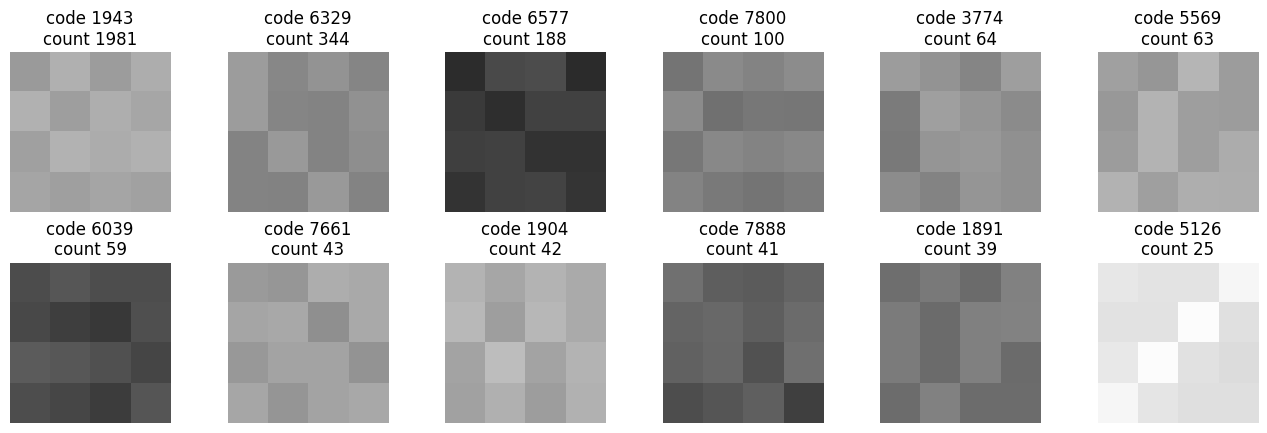

In [12]:
# Jupyter Cell 6 — (Optional) visualize the most-used codes in THIS image (and their exemplar patches)
# If your codebook is huge, this helps sanity-check what it's picking.

@torch.no_grad()
def show_top_exemplars_for_image(idx: torch.Tensor, exemplars: torch.Tensor, topk: int = 12):
    # idx: [L]
    counts = torch.bincount(idx, minlength=exemplars.shape[0])
    vals, inds = torch.topk(counts, k=min(topk, exemplars.shape[0]))
    inds = inds[vals > 0]
    vals = vals[vals > 0]

    n = inds.numel()
    if n == 0:
        print("No exemplars used?")
        return

    cols = min(6, n)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(2.2*cols, 2.2*rows))
    axes = axes.flatten() if n > 1 else [axes]

    for i in range(rows*cols):
        axes[i].axis("off")

    for i in range(n):
        j = int(inds[i].item())
        patch = to_01(exemplars[j]).clamp(0,1).cpu()  # [C,P,P]
        if patch.shape[0] == 1:
            axes[i].imshow(patch[0], vmin=0, vmax=1, cmap="gray")
        else:
            axes[i].imshow(patch.permute(1,2,0))
        axes[i].set_title(f"code {j}\ncount {int(vals[i].item())}")
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

show_top_exemplars_for_image(idx, exemplar_patches, topk=12)


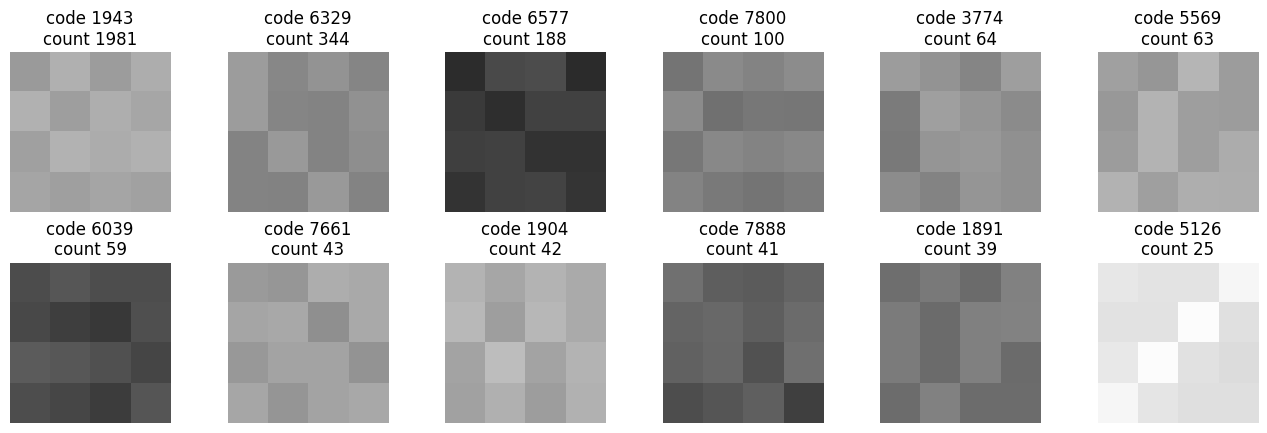

In [13]:
# Jupyter Cell 6 — (Optional) visualize the most-used codes in THIS image (and their exemplar patches)
# If your codebook is huge, this helps sanity-check what it's picking.

@torch.no_grad()
def show_top_exemplars_for_image(idx: torch.Tensor, exemplars: torch.Tensor, topk: int = 12):
    # idx: [L]
    counts = torch.bincount(idx, minlength=exemplars.shape[0])
    vals, inds = torch.topk(counts, k=min(topk, exemplars.shape[0]))
    inds = inds[vals > 0]
    vals = vals[vals > 0]

    n = inds.numel()
    if n == 0:
        print("No exemplars used?")
        return

    cols = min(6, n)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(2.2*cols, 2.2*rows))
    axes = axes.flatten() if n > 1 else [axes]

    for i in range(rows*cols):
        axes[i].axis("off")

    for i in range(n):
        j = int(inds[i].item())
        patch = to_01(exemplars[j]).clamp(0,1).cpu()  # [C,P,P]
        if patch.shape[0] == 1:
            axes[i].imshow(patch[0], vmin=0, vmax=1, cmap="gray")
        else:
            axes[i].imshow(patch.permute(1,2,0))
        axes[i].set_title(f"code {j}\ncount {int(vals[i].item())}")
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

show_top_exemplars_for_image(idx, exemplar_patches, topk=12)
